[[0.03589744 0.04615385 0.04615385 ... 0.4923077  0.4871795  0.45128205]
 [0.03589744 0.04615385 0.05128205 ... 0.53846157 0.52307695 0.4923077 ]
 [0.04102564 0.05128205 0.05641026 ... 0.5538462  0.53846157 0.4974359 ]
 ...
 [0.03589744 0.04615385 0.05641026 ... 0.52820516 0.51282054 0.4871795 ]
 [0.04102564 0.04615385 0.04615385 ... 0.50256413 0.4974359  0.45128205]
 [0.03589744 0.04102564 0.05128205 ... 0.42564103 0.41025642 0.36923078]]
[[0.03311258 0.03311258 0.03311258 ... 0.53642386 0.53642386 0.53642386]
 [0.03311258 0.03311258 0.03311258 ... 0.54304636 0.54304636 0.54966885]
 [0.03311258 0.03311258 0.03311258 ... 0.5562914  0.5562914  0.5562914 ]
 ...
 [0.0397351  0.0397351  0.0397351  ... 0.53642386 0.5298013  0.5298013 ]
 [0.0397351  0.0397351  0.0397351  ... 0.51655626 0.5231788  0.5231788 ]
 [0.01324503 0.03311258 0.03311258 ... 0.5033113  0.50993377 0.50993377]]
Root Mean Squared Error (RMSE): 0.03529681637883186


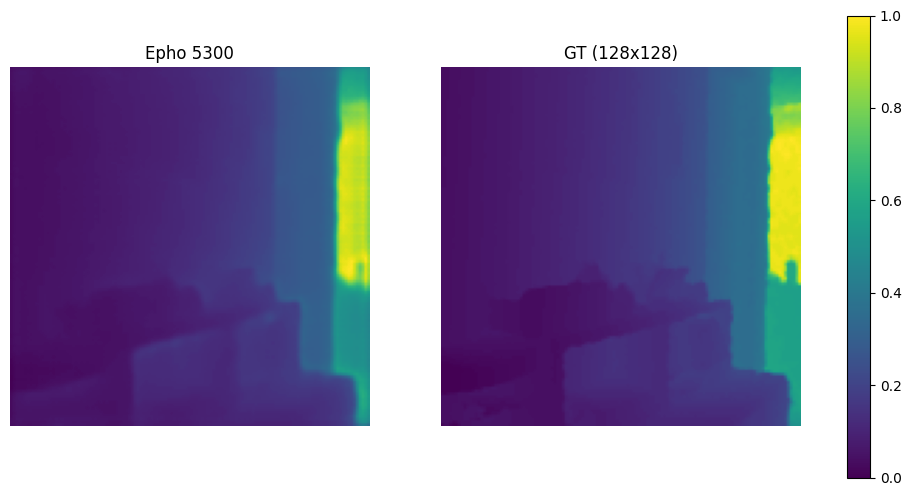

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_and_normalize_depth_map(filename, resize_to=None):
    # 读取三通道深度图
    depth_map = cv2.imread(filename)
    
    if depth_map is None:
        print(f"Failed to load depth map: {filename}")
        return None

    # 调整深度图大小（如果需要）
    if resize_to is not None:
        depth_map = cv2.resize(depth_map, resize_to, interpolation=cv2.INTER_AREA)

    # 提取单通道深度信息（假设深度信息在第一个通道）
    single_channel_depth_map = depth_map[:, :, 0]
    min_val, max_val =(0.0, 1.0)
    single_channel_depth_map = single_channel_depth_map.astype(np.float32)
    single_channel_depth_map = (single_channel_depth_map - single_channel_depth_map.min()) / (single_channel_depth_map.max() - single_channel_depth_map.min() + 1e-8)
    single_channel_depth_map = single_channel_depth_map * (max_val - min_val) + min_val
    # print(single_channel_depth_map)
    # 正常化深度图以便于显示
    # depth_map_normalized = cv2.normalize(single_channel_depth_map, None, 0, 255, cv2.NORM_MINMAX)
    # depth_map_normalized = np.uint8(depth_map_normalized)
    print(single_channel_depth_map)

    return single_channel_depth_map

def calculate_rmse(image1, image2):
    # 确保两张图像尺寸相同
    if image1.shape != image2.shape:
        raise ValueError("The dimensions of the two images do not match.")
    
    # 计算均方根误差
    mse = np.mean(abs((image1 - image2)) ** 2)

    rmse = np.sqrt(mse)
    return rmse

# 读取并处理两张深度图
depth_map1 = read_and_normalize_depth_map(r'C:\Users\10528\Desktop\FocusDiff\generate_imgs\MFFW\20240628_125256\epoch_5350\png_imgs\MFFW_03.png')
depth_map2 = read_and_normalize_depth_map(r'C:\Users\10528\Desktop\FocusDiff\data\NYUv2\train_depth\00008_depth.png',resize_to=(128, 128))

# 将第一张深度图也调整为128x128以计算RMSE
depth_map1_resized = cv2.resize(depth_map1, (128, 128), interpolation=cv2.INTER_AREA)

# 计算均方根误差
if depth_map1_resized is not None and depth_map2 is not None:
    rmse = calculate_rmse(depth_map1, depth_map2)
    print(f"Root Mean Squared Error (RMSE): {rmse}")

# 创建子图
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# 显示第一张深度图
if depth_map1 is not None:
    axs[0].imshow(depth_map1)
    axs[0].set_title('Epho 5300')
    axs[0].axis('off')
    
# 显示第二张深度图
if depth_map2 is not None:
    axs[1].imshow(depth_map2)
    axs[1].set_title('GT (128x128)')
    axs[1].axis('off')

# 显示颜色条
fig.colorbar(axs[0].images[0], ax=axs, orientation='vertical', fraction=.1)

plt.show()

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
def read_and_normalize_depth_map(filename, resize_to=None):
    # 读取三通道深度图
    depth_map = cv2.imread(filename)
    
    if depth_map is None:
        print(f"Failed to load depth map: {filename}")
        return None

    # 调整深度图大小（如果需要）
    if resize_to is not None:
        depth_map = cv2.resize(depth_map, resize_to, interpolation=cv2.INTER_AREA)

    # 提取单通道深度信息（假设深度信息在第一个通道）
    single_channel_depth_map = depth_map[:, :, 0]
    min_val, max_val =(0.0, 1.0)
    single_channel_depth_map = single_channel_depth_map.astype(np.float32)
    single_channel_depth_map = (single_channel_depth_map - single_channel_depth_map.min()) / (single_channel_depth_map.max() - single_channel_depth_map.min() + 1e-8)
    single_channel_depth_map = single_channel_depth_map * (max_val - min_val) + min_val
    # 正常化深度图以便于显示
    # depth_map_normalized = np.uint8(single_channel_depth_map)
    return single_channel_depth_map

def calculate_rmse(image1, image2):
    # 确保两张图像尺寸相同
    if image1.shape != image2.shape:
        raise ValueError("The dimensions of the two images do not match.")
    
    # 计算均方根误差
    mse = np.mean(((image1 - image2)) ** 2)
    rmse = np.sqrt(mse)
    return rmse

def calculate_total_rmse_by_order(folder1, folder2, resize_to=(128, 128)):
    total_rmse = 0
    count = 0

    files1 = sorted([os.path.join(folder1, f) for f in os.listdir(folder1) if os.path.isfile(os.path.join(folder1, f))])
    files2 = sorted([os.path.join(folder2, f) for f in os.listdir(folder2) if os.path.isfile(os.path.join(folder2, f))])

    # 确保两个文件夹中的文件数量相同
    min_length = min(len(files1), len(files2))

    for i in range(min_length):
        file1 = files1[i]
        file2 = files2[i]

        depth_map1 = read_and_normalize_depth_map(file1)
        depth_map2 = read_and_normalize_depth_map(file2, resize_to)

        if depth_map1 is not None and depth_map2 is not None:
            rmse = calculate_rmse(depth_map1, depth_map2)
            total_rmse += rmse
            count += 1

    if count > 0:
        average_rmse = total_rmse / count
    else:
        average_rmse = None

    return average_rmse

# 文件夹路径
folder1 = r'C:\Users\10528\Desktop\FusionDiff\generate_imgs\MFFW\20240628_125256\epoch_5350\png_imgs'
folder2 = r'C:\Users\10528\Desktop\FusionDiff\data\NYUv2\train_depth'

average_rmse = calculate_total_rmse_by_order(folder1, folder2, resize_to=(128, 128))

if average_rmse is not None:
    print(f"Average RMSE: {average_rmse}")
else:
    print("No matching image pairs found.")


In [ ]:
import torch

# 假设这两个张量
tensor1 = torch.randn(2, 3, 2, 2)  # (2, 3, 128, 128)
tensor2 = torch.randn(2, 2, 3, 2, 2)  # (2, 5, 3, 128, 128)
print(tensor1)
print(tensor2)
# 扩展 tensor1 的形状到 (2, 1, 3, 128, 128)
tensor1_expanded = tensor1.unsqueeze(1).expand_as(tensor2)
print(tensor1_expanded)
# 在第1维（不同焦距图像数量）进行拼接
result = torch.cat(( tensor1_expanded,tensor2,), dim=2)
print(result)
print(result.shape)  # 输出形状 (2, 6, 3, 128, 128)


In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sat Aug 17 18:46:20 2019

@author: 不用先生
"""

import cv2
import numpy as np

input_fn='03.jpg'

def my_guidedFilter_oneChannel(srcImg,guidedImg,rad=9,eps=0.01):
    
    srcImg=srcImg/255.0
    guidedImg=guidedImg/255.0
    img_shape=np.shape(srcImg)
    
#    dstImg=np.zeros(img_shape,dtype=float)
#    
#    P_mean=np.zeros(img_shape,dtype=float)
#    I_mean=np.zeros(img_shape,dtype=float)
#    I_square_mean=np.zeros(img_shape,dtype=float)
#    I_mul_P_mean=np.zeros(img_shape,dtype=float)
#    var_I=np.zeros(img_shape,dtype=float)
#    cov_I_P=np.zeros(img_shape,dtype=float)
#    
#    a=np.zeros(img_shape,dtype=float)
#    b=np.zeros(img_shape,dtype=float)
#    a_mean=np.zeros(img_shape,dtype=float)
#    b_mean=np.zeros(img_shape,dtype=float)
    
    P_mean=cv2.boxFilter(srcImg, -1, (rad, rad), normalize=True) 
    I_mean=cv2.boxFilter(guidedImg,-1, (rad, rad), normalize=True) 
    
    I_square_mean=cv2.boxFilter(np.multiply(guidedImg,guidedImg), -1, (rad, rad), normalize=True) 
    I_mul_P_mean=cv2.boxFilter(np.multiply(srcImg,guidedImg), -1, (rad, rad), normalize=True)
    
    var_I=I_square_mean-np.multiply(I_mean,I_mean)
    cov_I_P=I_mul_P_mean-np.multiply(I_mean,P_mean)
    
    a=cov_I_P/(var_I+eps)
    b=P_mean-np.multiply(a,I_mean)
    
    a_mean=cv2.boxFilter(a, -1, (rad, rad), normalize=True) 
    b_mean=cv2.boxFilter(b, -1, (rad, rad), normalize=True) 
    
    dstImg=np.multiply(a_mean,guidedImg)+b_mean
    
    return dstImg*255.0
    

def my_guidedFilter_threeChannel(srcImg,guidedImg,rad=9,eps=0.01):
    
    img_shape=np.shape(srcImg)

    dstImg=np.zeros(img_shape,dtype=float)

    for ind in range(0,img_shape[2]):
        dstImg[:,:,ind]=my_guidedFilter_oneChannel(srcImg[:,:,ind],
              guidedImg[:,:,ind],rad,eps)
    
    dstImg=dstImg.astype(np.uint8)
    
    return dstImg


def main():
    img=cv2.imread(input_fn)
    print(np.shape(img))

    dstimg=my_guidedFilter_threeChannel(img,img,9,0.01)
    print(np.shape(dstimg))
#    cv2.imwrite('output.jpg',dstimg)
    cv2.imshow('output',dstimg)
    cv2.waitKey(0)
    
if __name__ == '__main__':
    main()


In [ ]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0.0, std=0.1):
    """
    向图像添加高斯噪声

    Args:
        image (torch.Tensor): 输入图像，形状为 (C, H, W)
        mean (float): 高斯噪声的均值
        std (float): 高斯噪声的标准差

    Returns:
        torch.Tensor: 添加高斯噪声后的图像
    """
    noise = torch.randn(image.size()) * std + mean
    noisy_image = image + noise
    noisy_image = torch.clamp(noisy_image, 0, 2)  # 将图像像素值限制在 [0, 1] 范围内
    return noisy_image, noise

def compute_noise_content(original_image, noisy_image):
    """
    计算图像中的噪声含量

    Args:
        original_image (torch.Tensor): 原始图像，形状为 (C, H, W)
        noisy_image (torch.Tensor): 添加噪声后的图像，形状为 (C, H, W)

    Returns:
        float: 噪声的均值
        float: 噪声的标准差
    """
    noise = noisy_image - original_image
    noise_mean = torch.mean(noise)
    noise_std = torch.std(noise)
    return noise_mean.item(), noise_std.item()

# 创建一个示例图像（例如：从0到1的随机图像）
image = torch.rand(3, 256, 256)  # 假设图像大小为 256x256，3个通道（RGB）

# 添加高斯噪声
noisy_image, noise = add_gaussian_noise(image, mean=0.0, std=0.3)

# 计算噪声含量
noise_mean, noise_std = compute_noise_content(image, noisy_image)

print(f"Noise Mean: {noise_mean}")
print(f"Noise Std: {noise_std}")

# 转换图像格式以便使用matplotlib显示
to_pil = transforms.ToPILImage()

original_image_pil = to_pil(image)
noisy_image_pil = to_pil(noisy_image)

# 显示原始图像和添加噪声后的图像
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_image_pil)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(noisy_image_pil)
ax[1].set_title('Noisy Image')
ax[1].axis('off')

plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
cost=torch.rand(3, 256, 256)
print(F.softmax(cost,1).size()) 

In [ ]:
class SKConv(nn.Module):
    def __init__(self, features, M=2, G=32, r=16, stride=1, L=32):
        """ Constructor
        Args:
            features: input channel dimensionality.
            M: the number of branchs.
            G: num of convolution groups.
            r: the ratio for compute d, the length of z.
            stride: stride, default 1.
            L: the minimum dim of the vector z in paper, default 32.
        """
        super(SKConv, self).__init__()
        d = max(int(features/r), L)
        self.M = M
        self.features = features
        self.convs = nn.ModuleList([])
        for i in range(M):
            self.convs.append(nn.Sequential(
                nn.Conv2d(features, features, kernel_size=3, stride=stride, padding=1, groups=G, bias=False),
                nn.BatchNorm2d(features),
                nn.ReLU(inplace=False)
            ))
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(nn.Conv2d(features, d, kernel_size=1, stride=1, bias=False),
                                nn.BatchNorm2d(d),
                                nn.ReLU(inplace=False))
        self.fcs = nn.ModuleList([])
        for i in range(M):
            self.fcs.append(
                 nn.Conv2d(d, features, kernel_size=1, stride=1)
            )
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x,y):
        
        batch_size = x.shape[0]
        
        feats = [conv(x) for conv in self.convs]      
        feats = torch.cat(feats, dim=1)
        feats = feats.view(batch_size, self.M, self.features, feats.shape[2], feats.shape[3])
        
        feats_U = torch.sum(feats, dim=1)
        feats_S = self.gap(feats_U)
        feats_Z = self.fc(feats_S)
 
        attention_vectors = [fc(feats_Z) for fc in self.fcs]
        attention_vectors = torch.cat(attention_vectors, dim=1)
        attention_vectors = attention_vectors.view(batch_size, self.M, self.features, 1, 1)
        attention_vectors = self.softmax(attention_vectors)
        
        feats_V = torch.sum(feats*attention_vectors, dim=1)
        
        return feats_V
net=SKConv(32,M=2, G=32, r=16, stride=1, L=32)
print(net(torch.randn(2,32,255,255)))

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
class FFParser(nn.Module):
    def __init__(self, dim=3, h=128, w=128):
        super().__init__()
        self.complex_weight = nn.Parameter(torch.randn(dim, h, w, 2, dtype=torch.float32) * 0.02)
        self.w = w
        self.h = h

    def forward(self, x, spatial_size=None):
        B, C, H, W = x.shape
        assert H == W, "height and width are not equal"
        if spatial_size is None:
            a = b = H
        else:
            a, b = spatial_size

        # x = x.view(B, a, b, C)
        x = x.to(torch.float32)
        # x = torch.fft.rfft2(x, dim=(2, 3), norm='ortho')
        weight = torch.view_as_complex(self.complex_weight)
        x = x * weight
        x = torch.fft.irfft2(x, s=(H, W), dim=(2, 3), norm='ortho')

        x = x.reshape(B, C, H, W)

        return x
net=FFParser(dim=3, h=128, w=128)
print(net(torch.randn(3,2,128,128)))

In [ ]:
from torch import nn
import torch
from torch.nn import functional as F
class LearnableGaussianBlur(nn.Module):
    def __init__(self,dim=3,h=128,w=128,kernel_size=5, initial_sigma=1.0):
        super(LearnableGaussianBlur, self).__init__()
        self.kernel_size = kernel_size
        self.sigma = nn.Parameter(torch.tensor(initial_sigma))
        self.complex_weight = nn.Parameter(torch.randn(dim, h, w, 2, dtype=torch.float32) * 0.02)

    def forward(self, x):
        kernel = self.create_gaussian_kernel(self.kernel_size, self.sigma)
        kernel = kernel.expand(x.size(1), 1, self.kernel_size, self.kernel_size)
        x = F.conv2d(x, kernel, padding=self.kernel_size // 2, groups=x.size(1))
        weight = torch.view_as_complex(self.complex_weight)
        return x*weight

    @staticmethod
    def create_gaussian_kernel(kernel_size, sigma):
        x = torch.arange(kernel_size, dtype=torch.float32) - kernel_size // 2
        x = x.repeat(kernel_size, 1)
        y = x.t()
        kernel = torch.exp(-(x**2 + y**2) / (2 * sigma**2))
        kernel = kernel / kernel.sum()
        return kernel.view(1, 1, kernel_size, kernel_size)
net=LearnableGaussianBlur(3)
print(net(torch.randn(2,3,128,128)))

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Sat Aug 17 18:46:20 2019

@author: 不用先生
"""

import cv2
import numpy as np

input_fn='03.jpg'

def my_guidedFilter_oneChannel(srcImg,guidedImg,rad=9,eps=0.01):
    
    srcImg=srcImg/255.0
    guidedImg=guidedImg/255.0
    img_shape=np.shape(srcImg)
    
#    dstImg=np.zeros(img_shape,dtype=float)
#    
#    P_mean=np.zeros(img_shape,dtype=float)
#    I_mean=np.zeros(img_shape,dtype=float)
#    I_square_mean=np.zeros(img_shape,dtype=float)
#    I_mul_P_mean=np.zeros(img_shape,dtype=float)
#    var_I=np.zeros(img_shape,dtype=float)
#    cov_I_P=np.zeros(img_shape,dtype=float)
#    
#    a=np.zeros(img_shape,dtype=float)
#    b=np.zeros(img_shape,dtype=float)
#    a_mean=np.zeros(img_shape,dtype=float)
#    b_mean=np.zeros(img_shape,dtype=float)
    
    P_mean=cv2.boxFilter(srcImg, -1, (rad, rad), normalize=True) 
    I_mean=cv2.boxFilter(guidedImg,-1, (rad, rad), normalize=True) 
    
    I_square_mean=cv2.boxFilter(np.multiply(guidedImg,guidedImg), -1, (rad, rad), normalize=True) 
    I_mul_P_mean=cv2.boxFilter(np.multiply(srcImg,guidedImg), -1, (rad, rad), normalize=True)
    
    var_I=I_square_mean-np.multiply(I_mean,I_mean)
    cov_I_P=I_mul_P_mean-np.multiply(I_mean,P_mean)
    
    a=cov_I_P/(var_I+eps)
    b=P_mean-np.multiply(a,I_mean)
    
    a_mean=cv2.boxFilter(a, -1, (rad, rad), normalize=True) 
    b_mean=cv2.boxFilter(b, -1, (rad, rad), normalize=True) 
    
    dstImg=np.multiply(a_mean,guidedImg)+b_mean
    
    return dstImg*255.0
    

def my_guidedFilter_threeChannel(srcImg,guidedImg,rad=9,eps=0.01):
    
    img_shape=np.shape(srcImg)

    dstImg=np.zeros(img_shape,dtype=float)

    for ind in range(0,img_shape[2]):
        dstImg[:,:,ind]=my_guidedFilter_oneChannel(srcImg[:,:,ind],
              guidedImg[:,:,ind],rad,eps)
    
    dstImg=dstImg.astype(np.uint8)
    
    return dstImg


def main():
    img=cv2.imread(input_fn)
    print(np.shape(img))

    dstimg=my_guidedFilter_threeChannel(img,img,9,0.01)
    print(np.shape(dstimg))
#    cv2.imwrite('output.jpg',dstimg)
    cv2.imshow('output',dstimg)
    cv2.waitKey(0)
    
if __name__ == '__main__':
    main()


Image data shape: (256, 256, 1)


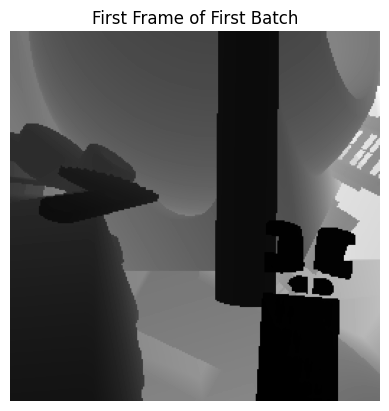

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 假设npy文件的路径为'image_data.npy'
npy_file_path = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\train\000001Dpt.npy'

# 读取npy文件
image_data = np.load(npy_file_path)

# 检查数据的形状
print("Image data shape:", image_data.shape)

# 显示第一个batch的第一帧图像
# 假设数据的形状为(2, 5, 3, 128, 128)
# 表示2个batch，每个batch有5帧图像，每帧图像有3个通道，尺寸为128x128

# 选择第一个batch的第一帧图像
# first_frame = image_data[0, 0]

# 转置图像数据以便正确显示
# 从 (3, 128, 128) 转换为 (128, 128, 3)
# first_frame = np.transpose(first_frame, (1, 2, 0))

# 显示图像
plt.imshow(image_data, cmap='gray')
plt.title("First Frame of First Batch")
plt.axis('off')
plt.show()


In [ ]:
import os
import shutil
import random

# 定义路径
data_dir = r'C:\Users\10528\Desktop\DEReD-main\data\DefocusNet\fs'
labels_dir = r'C:\Users\10528\Desktop\DEReD-main\data\DefocusNet\depth'
rgb_images_dir = r'C:\Users\10528\Desktop\DEReD-main\data\DefocusNet\aif'

train_data_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\train'
train_labels_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\train_labels'
train_rgb_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\train_rgb1'

test_data_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\test'
test_labels_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\test_labels'
test_rgb_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\test_rgb1'

# 创建新的文件夹
os.makedirs(train_data_dir, exist_ok=True)
os.makedirs(train_labels_dir, exist_ok=True)
os.makedirs(train_rgb_dir, exist_ok=True)

os.makedirs(test_data_dir, exist_ok=True)
os.makedirs(test_labels_dir, exist_ok=True)
os.makedirs(test_rgb_dir, exist_ok=True)

# 获取所有数据和标签文件
data_files = sorted(os.listdir(data_dir))
label_files = sorted(os.listdir(labels_dir))
rgb_files = sorted(os.listdir(rgb_images_dir))
# 每五张图像对应一个标签
assert len(data_files) == 5 * len(label_files), "数据和标签数量不匹配"

# 将图像和标签配对
pairs = [(data_files[i:i + 5], label_files[i // 5], rgb_files[i // 5]) for i in range(0, len(data_files), 5)]

# 打乱顺序
random.shuffle(pairs)

# 分成训练集和测试集（例如 80% 训练集，20% 测试集）
split_index = int(0.8 * len(pairs))
train_pairs = pairs[:split_index]
test_pairs = pairs[split_index:]

# 复制文件到训练集文件夹
for img_files, label_file, rgbfile in train_pairs:
    for img_file in img_files:
        shutil.copy(os.path.join(data_dir, img_file), os.path.join(train_data_dir, img_file))
    shutil.copy(os.path.join(labels_dir, label_file), os.path.join(train_labels_dir, label_file))
    shutil.copy(os.path.join(rgb_images_dir, rgbfile), os.path.join(train_rgb_dir, rgbfile))
    

# 复制文件到测试集文件夹
for img_files, label_file, rgbfile in test_pairs:
    for img_file in img_files:
        shutil.copy(os.path.join(data_dir, img_file), os.path.join(test_data_dir, img_file))
    shutil.copy(os.path.join(labels_dir, label_file), os.path.join(test_labels_dir, label_file))
    shutil.copy(os.path.join(rgb_images_dir, rgbfile), os.path.join(test_rgb_dir, rgbfile))

print("数据分割完成。")



In [1]:
import os
import numpy as np
import cv2

# 定义路径
npy_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\train'
output_dir = r'C:\Users\10528\Desktop\FocusDiff\data\DefocusNet\rgb'
os.makedirs(output_dir, exist_ok=True)

# 获取所有 .npy 文件
npy_files = sorted([f for f in os.listdir(npy_dir) if f.endswith('.npy')])

for npy_file in npy_files:
    # 读取 .npy 文件
    npy_path = os.path.join(npy_dir, npy_file)
    numpy_image = np.load(npy_path)
    
    # 检查图像形状并转换为适当的格式
    if numpy_image.ndim == 2:  # 如果是单通道灰度图像
        numpy_image = np.expand_dims(numpy_image, axis=2)  # 扩展为 (H, W, 1)
    if numpy_image.shape[2] == 1:  # 如果通道数为1
        numpy_image = np.repeat(numpy_image, 3, axis=2)  # 重复通道以生成 RGB 图像
    plt.imshow(numpy_image, cmap='gray')
    plt.show()

    # 确保图像数据类型为 uint8
    if numpy_image.dtype != np.uint8:
        numpy_image = (numpy_image * 255).astype(np.uint8)
    
    # 定义输出图像路径
    image_name = os.path.splitext(npy_file)[0] + '.png'
    output_path = os.path.join(output_dir, image_name)
    
    # 保存图像文件
    cv2.imwrite(output_path, numpy_image)

print("所有 .npy 文件已转换并保存为图像。")


KeyboardInterrupt: 